**Specifications**

In [46]:
fs = 44100 # samples/seconds 1/fs ms between samples
fc = 4000 # carrier wave frequency in Hz 
Ts = 2.2676e-3 # each symbol is 2.2676 ms long (chosen so N = fs*Ts = 100 samples exactly)
mu = 0.00022676 # maximum delay of the channel in seconds (0.22676 ms = Ts/10)
import numpy as np
import matplotlib.pyplot as plt

N = int(round(fs * Ts)) # number of samples per symbol (= 100)
mu = int(round(fs * mu)) # maximum delay of the channel in samples (= 10 samples)
alpha = 3/18 # multipath amplitude coefficient

**Random Bit Generation**

In [47]:
bits = np.random.randint(0, 2, 1000000) # generate random bits to transmit

**I/Q Mapping**

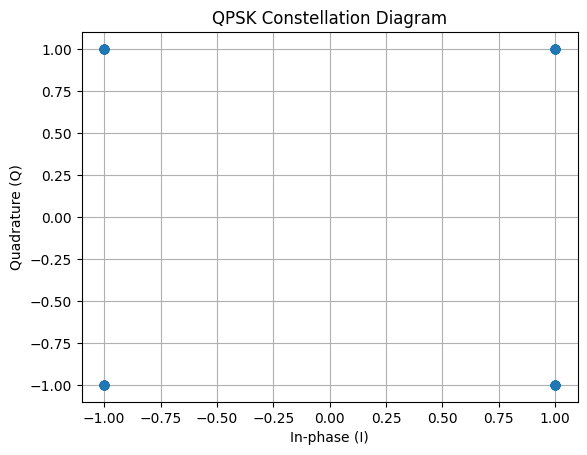

In [48]:
b = bits.reshape(-1, 2) # reshape bits into pairs for QPSK modulation
aI = np.where(b[:, 0] == 0,  1.0, -1.0)  # map the first bit of each pair to the in-phase component
aQ = np.where(b[:, 1] == 0,  1.0, -1.0)  # map the second bit of each pair to the quadrature component

a = aI + 1j * aQ # combine in-phase and quadrature components

plt.plot(aI[:100], aQ[:100], 'o')
plt.xlabel('In-phase (I)'); plt.ylabel('Quadrature (Q)')
plt.title('QPSK Constellation Diagram')
plt.grid(); plt.show()

**Pulse generation**

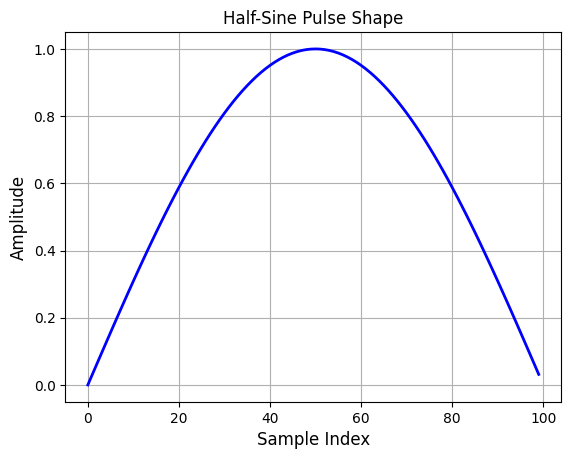

In [49]:
p = np.sin(np.pi * np.arange(N) / N) # Base pulse (half-sine)
plt.plot(p, 'b-', lw=2)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.title('Half-Sine Pulse Shape', fontsize=12)
plt.grid()
plt.show()

**Baseband Signal Generation**

In [50]:
Ns = len(a) # number of symbols to transmit

I_up = np.zeros(Ns * N)
Q_up = np.zeros(Ns * N)
I_up[::N] = aI
Q_up[::N] = aQ
I_bb = np.convolve(I_up, p, mode='full')[:Ns * N]
Q_bb = np.convolve(Q_up, p, mode='full')[:Ns * N]

**Carrier Generation**

In [51]:
n  = np.arange(Ns * N) # time index for the entire transmitted signal
cos_c = np.cos(2 * np.pi * fc * n / fs) # carrier wave for upconversion
sin_c = np.sin(2 * np.pi * fc * n / fs) # carrier wave for upconversion

**Modulation**

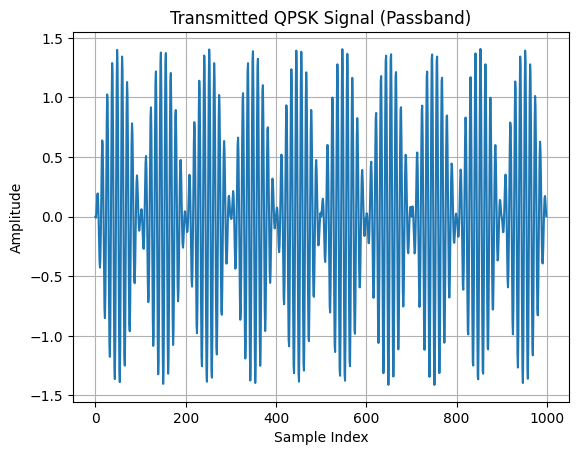

In [52]:
s_passband = I_bb * cos_c - Q_bb * sin_c   # upconvert to passband
plt.plot(s_passband[:1000]) # plot the first 1000 samples
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Transmitted QPSK Signal (Passband)')
plt.grid()
plt.show()

**Channel**

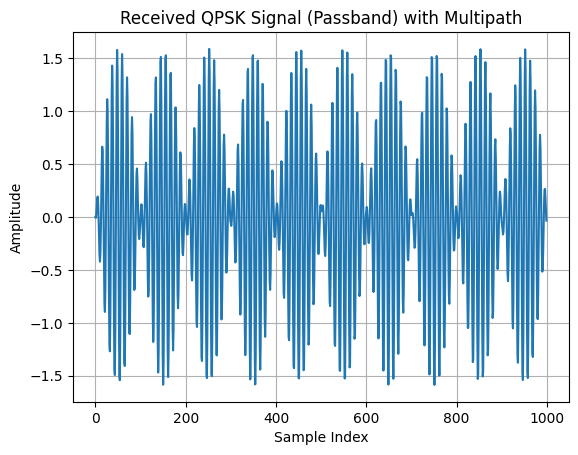

In [53]:
s_delayed = np.concatenate([np.zeros(mu), s_passband[:-mu]])
r = np.sqrt(1 - alpha**2) * s_passband + alpha * s_delayed
plt.plot(r[:1000])
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Received QPSK Signal (Passband) with Multipath')
plt.grid()
plt.show()

In [54]:
delay_samples = mu
delay_seconds = delay_samples / fs

P0 = 1 - alpha**2
P1 = alpha**2

delays = np.array([0, delay_seconds])
powers = np.array([P0, P1])

mean_delay = np.sum(powers * delays) / np.sum(powers)
tau_rms = np.sqrt(np.sum(powers * (delays - mean_delay)**2) / np.sum(powers))

Bc_50 = 1 / (5 * tau_rms)
Bc_90 = 1 / (50 * tau_rms)
Bc_simple = 1 / delay_seconds

B_signal = fs / N

print(delay_samples)
print(delay_seconds)
print(tau_rms)
print(Bc_simple)
print(Bc_50)
print(Bc_90)
print(B_signal)

if B_signal < Bc_50:
    print("Narrowband assumption is satisfied.")
else:
    print("Narrowband assumption is not clearly satisfied.")

print("Coherence time is very large (static channel)")

10
0.00022675736961451248
3.726429694570179e-05
4410.0
5367.067579227971
536.7067579227971
441.0
Narrowband assumption is satisfied.
Coherence time is very large (static channel)


**Noise Generator**

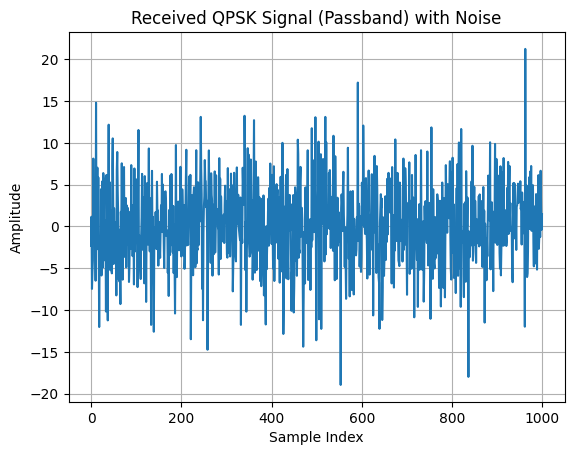

In [55]:
sigma = 5.0
noise = sigma * np.random.randn(len(r))
r = r + noise
plt.plot(r[:1000])
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Received QPSK Signal (Passband) with Noise')
plt.grid()
plt.show()

Eb/N0 =  0 dB  BER = 5.81e-02
Eb/N0 =  1 dB  BER = 3.93e-02
Eb/N0 =  2 dB  BER = 2.44e-02
Eb/N0 =  3 dB  BER = 1.37e-02
Eb/N0 =  4 dB  BER = 6.77e-03
Eb/N0 =  5 dB  BER = 2.95e-03
Eb/N0 =  6 dB  BER = 1.10e-03
Eb/N0 =  7 dB  BER = 3.20e-04
Eb/N0 =  8 dB  BER = 7.70e-05
Eb/N0 =  9 dB  BER = 7.00e-06
Eb/N0 = 10 dB  BER = 1.00e-06
Eb/N0 = 11 dB  BER = 0.00e+00
Eb/N0 = 12 dB  BER = 0.00e+00


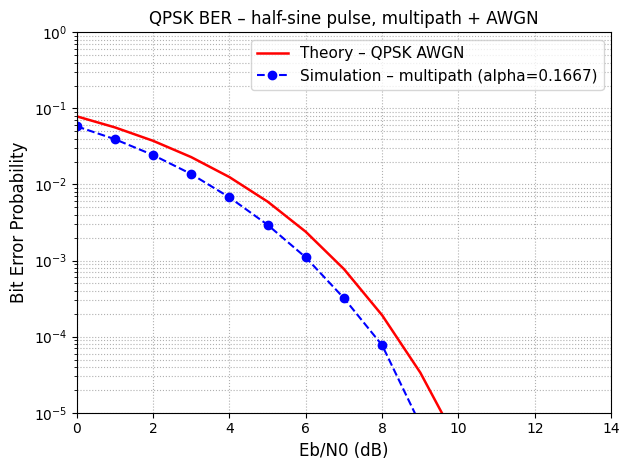

In [ ]:
from scipy.special import erfc

# SNR points
EbN0_dB  = np.arange(0, 13, 1) # 0..14 dB
EbN0_lin = 10 ** (EbN0_dB / 10.0)

Eb_disc = np.sum(s_passband**2) / (len(bits)) # discrete energy per bit

BER_sim = np.zeros(len(EbN0_dB))

for i, EbN0 in enumerate(EbN0_lin):
    sigma = np.sqrt(Eb_disc / (2.0 * EbN0))

    # Channel
    s_delayed = np.concatenate([np.zeros(mu), s_passband[:-mu]])
    r = np.sqrt(1 - alpha**2) * s_passband + alpha * s_delayed
    r = r + sigma * np.random.randn(len(r))

    # Downconvert
    r_I = 2.0 * r * cos_c
    r_Q = -2.0 * r * sin_c

    # Sample at MF output peaks (offset N-1 within each symbol period)
    y_I = r_I.reshape(Ns, N) @ p
    y_Q  = r_Q.reshape(Ns, N) @ p

    # Hard decisions
    bits_I_hat = (y_I < 0).astype(int)
    bits_Q_hat = (y_Q < 0).astype(int)
    bits_hat   = np.column_stack([bits_I_hat, bits_Q_hat]).flatten()
    BER_sim[i] = np.sum(bits != bits_hat) / len(bits)
    print(f'Eb/N0 = {EbN0_dB[i]:2d} dB  BER = {BER_sim[i]:.2e}')

# Theoretical QPSK BER in AWGN
BER_theory = 0.5 * erfc(np.sqrt(EbN0_lin))

plt.semilogy(EbN0_dB, BER_theory, 'r-',   lw=1.8, label='Theory – QPSK AWGN')
plt.semilogy(EbN0_dB, BER_sim,    'bo--',  lw=1.5, markersize=6,
             label=f'Simulation – multipath (alpha={alpha:.4f})')
plt.xlabel('Eb/N0 (dB)', fontsize=12)
plt.ylabel('Bit Error Probability', fontsize=12)
plt.title('QPSK BER – half-sine pulse, multipath + AWGN', fontsize=12)
plt.xlim([0, 14]); plt.ylim([1e-5, 1])
plt.legend(fontsize=11)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.savefig('ber_task1.pdf', bbox_inches='tight')
plt.show()